###author: xiaoniao xiao
###data:2026.5.21
###data:mdga2-analysis

In [1]:
source('~/hanshu/lib.R')

Attaching SeuratObject

Seurat v4 was just loaded with SeuratObject v5; disabling v5 assays and
validation routines, and ensuring assays work in strict v3/v4
compatibility mode


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ lubridate 1.9.3     ✔ stringr   1.5.1
✔ purrr     1.2.0     ✔ tibble    3.2.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ data.table::between() masks dplyr::between()
✖ readr::col_factor()   masks scales::col_factor()
✖ purrr::discard()      masks scales::discard()
✖ dplyr::filter()       masks stats::filter()
✖ data.table::first()   masks

In [2]:
library(sceasy)
library(reticulate)
library(tidyverse)
use_condaenv('~/miniforge3/envs/danxibao')
loompy <- reticulate::import('loompy')

Loading required package: reticulate



In [3]:
sceasy::convertFormat('../output/sce.anno.h5ad', from="anndata", to="seurat",
                      outFile='../output/sce.anno.rds')

X -> counts

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from scvi_extra_categorical_covs_ to scviextracategoricalcovs_”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from scvi_extra_continuous_covs_ to scviextracontinuouscovs_”


An object of class Seurat 
26376 features across 141534 samples within 1 assay 
Active assay: RNA (26376 features, 0 variable features)
 2 layers present: counts, data
 4 dimensional reductions calculated: scVI, umap, X_scvi_extra_categorical_covs, X_scvi_extra_continuous_covs

In [2]:
scRNA = read_rds('../output/sce.anno.rds')

In [6]:
color = c("#AB1197FF",
                "#E391BA",
                "#D4D98A",
                "#FF7F0EFF",
                "#EDC962",
                "#C5B0D5FF",
                #"#2BAE9E",
                "#215189")

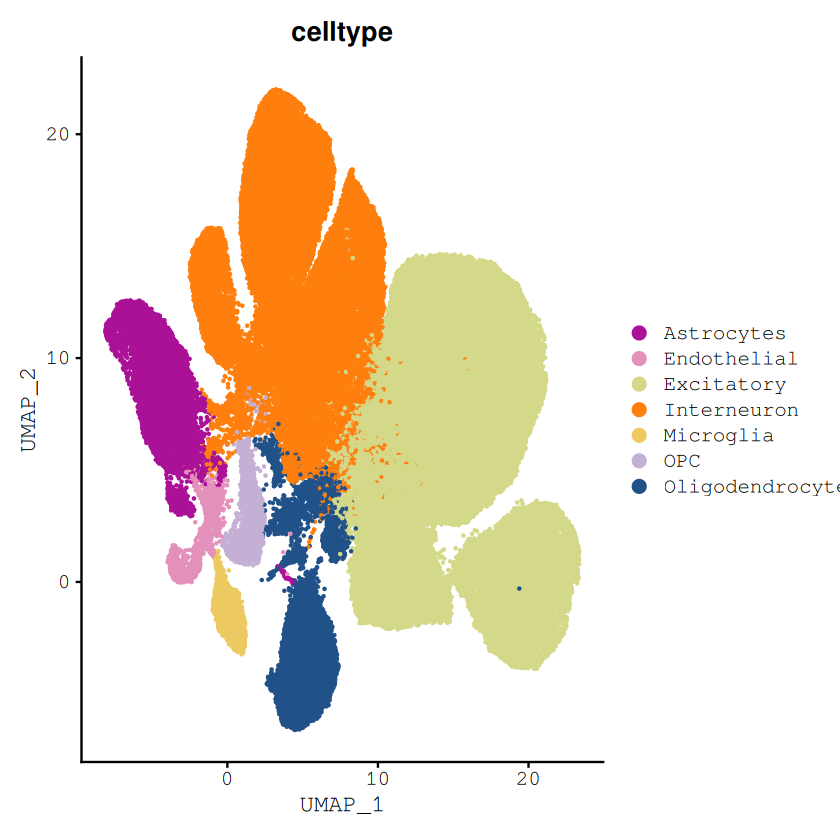

In [7]:
DimPlot(scRNA,cols = color,group.by = 'celltype',raster = F)

In [8]:
table(scRNA$group)


Disease  Health Therapy 
  47416   42753   51365 

In [9]:
sce.all = scRNA

In [12]:
sce.all = qs::qread('../output/Exc/Exc.anno.qs')

In [13]:
unique(sce.all$celltype2)

[1] "Exc_6"  "Exc_2"  "Exc_4"  "Exc_7"  "Exc_3"  "Exc_9"  "Exc_0"  "Exc_10"
 [9] "Exc_11" "Exc_5"  "Exc_1"  "Exc_8"

In [14]:
sc_Disease = sce.all[,sce.all$group %in% c('Disease','Health')]

In [15]:
scRNA = sc_Disease

In [17]:
table(scRNA$celltype2)


 Exc_0  Exc_1 Exc_10 Exc_11  Exc_2  Exc_3  Exc_4  Exc_5  Exc_6  Exc_7  Exc_8 
  8876  10018    608    270   5153   4963   2764   5122   2012   1783   2548 
 Exc_9 
  1175 

In [ ]:
####---- Load R Packages ----####
library(Seurat)
library(tidyverse)
library(ggh4x)
library(ggfun)
library(ggnewscale)
library(grid)
library(clusterProfiler)
library(org.Mm.eg.db)
options(timeout = 99999)
# 1. 
DefaultAssay(scRNA) <- "RNA"

# --- 
message("=========================================")

scRNA <- NormalizeData(scRNA, normalization.method = "LogNormalize", scale.factor = 10000)

# --- 
Idents(scRNA) <- "celltype2" 

# 
celltypes <- unique(scRNA@meta.data$celltype2)
celltypes <- celltypes[!is.na(celltypes)]

# 
fig_base_dir <- "../figure/Disease/celltype2/"
out_base_dir <- "../output/Disease/celltype2/"

# 2. 
for (ct in celltypes) {
  message("=========================================")
  
  
  # 
  ct_fig_dir <- paste0(fig_base_dir, ct, "/")
  ct_out_dir <- paste0(out_base_dir, ct, "/")
  if(!dir.exists(ct_fig_dir)) dir.create(ct_fig_dir, recursive = TRUE)
  if(!dir.exists(ct_out_dir)) dir.create(ct_out_dir, recursive = TRUE)
  
  # 
  de_results <- tryCatch({
    FindMarkers(scRNA, 
                subset.ident = ct, 
                group.by = "group",
                ident.1 = "Disease",   # 
                ident.2 = "Health")   # 
  }, error = function(e) {
    
    return(NULL)
  })
  
  if(is.null(de_results) || nrow(de_results) == 0) next
  
  # 
  fc_col <- grep("avg_log", colnames(de_results), value = TRUE)[1] 
  
  de_sig <- de_results %>% 
    rownames_to_column("Gene") %>%
    dplyr::filter(p_val < 0.05 & abs(!!sym(fc_col)) > 0.25)
  
  if(nrow(de_sig) == 0) {
    
    next
  }
  
  # 
  de_up <- de_sig %>% dplyr::filter(!!sym(fc_col) > 0.25)
  de_down <- de_sig %>% dplyr::filter(!!sym(fc_col) < -0.25)
  
  # 
  write.csv(de_sig, file = paste0(ct_out_dir, ct, "_Total_DEGs.csv"), row.names = FALSE)
  write.csv(de_up, file = paste0(ct_out_dir, ct, "_Up_DEGs.csv"), row.names = FALSE)
  write.csv(de_down, file = paste0(ct_out_dir, ct, "_Down_DEGs.csv"), row.names = FALSE)
  
  
  
  # ---
  deg_list <- list("Total" = de_sig, "Up" = de_up, "Down" = de_down)
  
  for (direction in names(deg_list)) {
    
    
    current_degs <- deg_list[[direction]]
    
    if(nrow(current_degs) == 0) {
      
      next
    }
    
    # --- 
    genes_for_enrich <- current_degs$Gene
    de_bitr <- suppressWarnings(tryCatch({
      bitr(geneID = genes_for_enrich, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = "org.Mm.eg.db")
    }, error = function(e) return(NULL)))
    
    if(is.null(de_bitr) || nrow(de_bitr) == 0) {
      
      next
    }
    gene_list <- de_bitr$ENTREZID
    
    # --- GO Enrichment ---
    deg_go <- suppressMessages(suppressWarnings(
      enrichGO(gene = gene_list, OrgDb = "org.Mm.eg.db", ont = "ALL", pvalueCutoff = 0.05, qvalueCutoff = 1)
    ))
    
    if(!is.null(deg_go) && nrow(deg_go) > 0) {
      deg_go_2 <- setReadable(deg_go, OrgDb = "org.Mm.eg.db", keyType = "ENTREZID") 
      deg_go_df <- as.data.frame(deg_go_2@result)
      write.csv(deg_go_df, file = paste0(ct_out_dir, ct, "_", direction, "_GO.csv"), row.names = FALSE)
    } else {
      deg_go_df <- data.frame()
      
    }
    
    # --- KEGG Enrichment ---
    deg_kegg <- suppressMessages(suppressWarnings(
      enrichKEGG(gene = gene_list, organism = "mmu", pvalueCutoff = 0.05, qvalueCutoff = 1)
    ))
    
    if(!is.null(deg_kegg) && nrow(deg_kegg) > 0) {
      deg_kegg_2 <- setReadable(deg_kegg, OrgDb = "org.Mm.eg.db", keyType = "ENTREZID")
      deg_kegg_df <- as.data.frame(deg_kegg_2@result)
      write.csv(deg_kegg_df, file = paste0(ct_out_dir, ct, "_", direction, "_KEGG.csv"), row.names = FALSE)
    } else {
      deg_kegg_df <- data.frame()
      
    }
    
    # 
    GO_top10 <- data.frame()
    if(nrow(deg_go_df) > 0) {
      GO_top10 <- deg_go_df %>%
        dplyr::group_by(ONTOLOGY) %>%
        dplyr::arrange(pvalue) %>% 
        dplyr::slice(1:10) %>%
        dplyr::ungroup()
    }
    
    KEGG_top10 <- data.frame()
    if(nrow(deg_kegg_df) > 0) {
      KEGG_top10 <- deg_kegg_df %>%
        dplyr::arrange(pvalue) %>% 
        dplyr::slice(1:10) %>% 
        dplyr::select(ID:Count) %>% 
        dplyr::mutate(ONTOLOGY = "KEGG") %>% 
        dplyr::select(ONTOLOGY, everything())
    }
    
    plot_df <- bind_rows(GO_top10, KEGG_top10) 
    
    if(nrow(plot_df) == 0) { 
      
      next 
    }
    
    # --- 
    plot_df <- plot_df %>%
      dplyr::mutate(ONTOLOGY = factor(ONTOLOGY, levels = rev(c("BP", "CC", "MF", "KEGG")), ordered = TRUE)) %>%
      dplyr::arrange(ONTOLOGY, desc(Count)) %>%
      dplyr::mutate(Description = str_remove(Description, pattern = "\\s*-\\s*Mus musculus \\(house mouse\\)")) %>%
      dplyr::mutate(Description = str_remove(Description, pattern = ",.*")) %>%
      dplyr::mutate(Description = make.unique(as.character(Description))) %>% 
      dplyr::mutate(Description = factor(Description, levels = rev(Description), ordered = TRUE))
    
    n_terms <- nrow(plot_df)
    
    # 
    p <- ggplot(plot_df) + 
      geom_point(data = plot_df %>% dplyr::filter(ONTOLOGY == "KEGG"),
                 aes(x = Count, y = interaction(Description, ONTOLOGY), fill = pvalue, size = Count), shape = 21) + 
      scale_fill_gradient(low = "#a1d99b", high = "#238b45", name = "KEGG pvalue") + 
      ggnewscale::new_scale_fill() + 
      geom_point(data = plot_df %>% dplyr::filter(ONTOLOGY == "MF"),
                 aes(x = Count, y = interaction(Description, ONTOLOGY), fill = pvalue, size = Count), shape = 21) + 
      scale_fill_gradient(low = "#a6bddb", high = "#0570b0", name = "MF pvalue") + 
      ggnewscale::new_scale_fill() + 
      geom_point(data = plot_df %>% dplyr::filter(ONTOLOGY == "CC"),
                 aes(x = Count, y = interaction(Description, ONTOLOGY), fill = pvalue, size = Count), shape = 21) + 
      scale_fill_gradient(low = "#fdd49e", high = "#d7301f", name = "CC pvalue") + 
      ggnewscale::new_scale_fill() +
      geom_point(data = plot_df %>% dplyr::filter(ONTOLOGY == "BP"),
                 aes(x = Count, y = interaction(Description, ONTOLOGY), fill = pvalue, size = Count), shape = 21) + 
      scale_fill_gradient(low = "#8c96c6", high = "#8c6bb1",  name = "BP pvalue") + 
      guides(y = "axis_nested",
             y.sec = guide_axis_manual(breaks = 1:n_terms, labels = plot_df$Description)) + 
      
      ggtitle(label = paste0(ct, " (Disease vs Health | ", direction, " DEGs)")) + 
      labs(x = "Count", y = "Description") + 
      scale_size(range = c(3, 7), guide = guide_legend(override.aes = list(fill = "#000000"))) + 
      theme_bw() + 
      theme(
        ggh4x.axis.nestline.y = element_line(linewidth = 3, color = c("#74c476", "#41b6c4", "#f46d43", "#9e9ac8")),
        ggh4x.axis.nesttext.y = element_text(colour = c("#74c476", "#41b6c4", "#f46d43", "#9e9ac8")),
        legend.background = element_rect(color = "#969696", linewidth = 0.5), 
        panel.border = element_rect(linewidth = 0.5),
        plot.margin = margin(t = 1, r = 1, b = 1, l = 1, unit = "cm"),
        axis.text.y = element_text(color = "black", size = 11), 
        axis.text.x = element_text(color = "#000000", size = 11),
        axis.text.y.left = element_blank(),
        axis.ticks.length.y.left = unit(10, "pt"),
        axis.ticks.y.left = element_line(color = NA),
        axis.title = element_text(color = "#000000", size = 15),
        plot.title = element_text(color = "#000000", size = 18, hjust = 0.5)
      ) + 
      coord_cartesian(clip = "off") + 
      # 
      annotation_custom(grob = rectGrob(gp = gpar(col = "#969696", lwd = 1.5, fill = NA)),
                        xmin = 3, xmax = 15,
                        ymin = n_terms + 0.85, ymax = n_terms + 2.25)
    
    # 
    plot_file <- paste0(ct_fig_dir, ct, "_", direction, "_GO_KEGG.pdf")
    ggsave(filename = plot_file, plot = p, height = 11, width = 12.5)
    
    
  } # 
  
} # 



In [17]:
table(sce.all$group)


Disease  Health Therapy 
  47416   42753   51365 

In [20]:
sc_Therapy = sce.all[,sce.all$group %in% c('Disease','Therapy')]

In [21]:
scRNA = sc_Therapy

In [22]:
table(scRNA$celltype2)


 Exc_0  Exc_1 Exc_10 Exc_11  Exc_2  Exc_3  Exc_4  Exc_5  Exc_6  Exc_7  Exc_8 
 11018   7042    495    597   6838   6115   5345   3735   2296   1712   1676 
 Exc_9 
  1152 

In [ ]:
####---- Load R Packages ----####
library(Seurat)
library(tidyverse)
library(ggh4x)
library(ggfun)
library(ggnewscale)
library(grid)
library(clusterProfiler)
library(org.Mm.eg.db)
options(timeout = 99999)

DefaultAssay(scRNA) <- "RNA"

message("=========================================")

scRNA <- NormalizeData(scRNA, normalization.method = "LogNormalize", scale.factor = 10000)

Idents(scRNA) <- "celltype2" 

celltypes <- unique(scRNA@meta.data$celltype2)
celltypes <- celltypes[!is.na(celltypes)]

fig_base_dir <- "../figure/Therapy/celltype2/"
out_base_dir <- "../output/Therapy/celltype2/"

for (ct in celltypes) {
  message("=========================================")
  
  ct_fig_dir <- paste0(fig_base_dir, ct, "/")
  ct_out_dir <- paste0(out_base_dir, ct, "/")
  if(!dir.exists(ct_fig_dir)) dir.create(ct_fig_dir, recursive = TRUE)
  if(!dir.exists(ct_out_dir)) dir.create(ct_out_dir, recursive = TRUE)
  
  de_results <- tryCatch({
    FindMarkers(scRNA, 
                subset.ident = ct, 
                group.by = "group",
                ident.1 = "Therapy",   
                ident.2 = "Disease")   
  }, error = function(e) {
    return(NULL)
  })
  
  if(is.null(de_results) || nrow(de_results) == 0) next
  
  fc_col <- grep("avg_log", colnames(de_results), value = TRUE)[1] 
  
  de_sig <- de_results %>% 
    rownames_to_column("Gene") %>%
    dplyr::filter(p_val < 0.05 & abs(!!sym(fc_col)) > 0.25)
  
  if(nrow(de_sig) == 0) {
    message(paste0("Skip: No significant DEGs after filtering - ", ct))
    next
  }
  
  de_up <- de_sig %>% dplyr::filter(!!sym(fc_col) > 0.25)
  de_down <- de_sig %>% dplyr::filter(!!sym(fc_col) < -0.25)
  
  write.csv(de_sig, file = paste0(ct_out_dir, ct, "_Total_DEGs.csv"), row.names = FALSE)
  write.csv(de_up, file = paste0(ct_out_dir, ct, "_Up_DEGs.csv"), row.names = FALSE)
  write.csv(de_down, file = paste0(ct_out_dir, ct, "_Down_DEGs.csv"), row.names = FALSE)
  
  message(paste0("Found ", nrow(de_up), " up-regulated genes, ", nrow(de_down), " down-regulated genes. Starting enrichment analysis..."))
  
  deg_list <- list("Total" = de_sig, "Up" = de_up, "Down" = de_down)
  
  for (direction in names(deg_list)) {
    message(paste0("    >> Processing enrichment analysis and plotting for [", direction, "] genes..."))
    
    current_degs <- deg_list[[direction]]
    
    if(nrow(current_degs) == 0) {
      message(paste0("      Skip: No genes found for [", direction, "] direction."))
      next
    }
    
    genes_for_enrich <- current_degs$Gene
    de_bitr <- suppressWarnings(tryCatch({
      bitr(geneID = genes_for_enrich, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = "org.Mm.eg.db")
    }, error = function(e) return(NULL)))
    
    if(is.null(de_bitr) || nrow(de_bitr) == 0) {
      message(paste0("      Skip: Unable to convert ENTREZID - ", direction))
      next
    }
    gene_list <- de_bitr$ENTREZID
    
    deg_go <- suppressMessages(suppressWarnings(
      enrichGO(gene = gene_list, OrgDb = "org.Mm.eg.db", ont = "ALL", pvalueCutoff = 0.05, qvalueCutoff = 1)
    ))
    
    if(!is.null(deg_go) && nrow(deg_go) > 0) {
      deg_go_2 <- setReadable(deg_go, OrgDb = "org.Mm.eg.db", keyType = "ENTREZID") 
      deg_go_df <- as.data.frame(deg_go_2@result)
      write.csv(deg_go_df, file = paste0(ct_out_dir, ct, "_", direction, "_GO.csv"), row.names = FALSE)
    } else {
      deg_go_df <- data.frame()
      message(paste0("      No significant GO enrichment results - ", direction))
    }
    
    deg_kegg <- suppressMessages(suppressWarnings(
      enrichKEGG(gene = gene_list, organism = "mmu", pvalueCutoff = 0.05, qvalueCutoff = 1)
    ))
    
    if(!is.null(deg_kegg) && nrow(deg_kegg) > 0) {
      deg_kegg_2 <- setReadable(deg_kegg, OrgDb = "org.Mm.eg.db", keyType = "ENTREZID")
      deg_kegg_df <- as.data.frame(deg_kegg_2@result)
      write.csv(deg_kegg_df, file = paste0(ct_out_dir, ct, "_", direction, "_KEGG.csv"), row.names = FALSE)
    } else {
      deg_kegg_df <- data.frame()
      message(paste0("      No significant KEGG enrichment results - ", direction))
    }
    
    GO_top10 <- data.frame()
    if(nrow(deg_go_df) > 0) {
      GO_top10 <- deg_go_df %>%
        dplyr::group_by(ONTOLOGY) %>%
        dplyr::arrange(pvalue) %>% 
        dplyr::slice(1:10) %>%
        dplyr::ungroup()
    }
    
    KEGG_top10 <- data.frame()
    if(nrow(deg_kegg_df) > 0) {
      KEGG_top10 <- deg_kegg_df %>%
        dplyr::arrange(pvalue) %>% 
        dplyr::slice(1:10) %>% 
        dplyr::select(ID:Count) %>% 
        dplyr::mutate(ONTOLOGY = "KEGG") %>% 
        dplyr::select(ONTOLOGY, everything())
    }
    
    plot_df <- bind_rows(GO_top10, KEGG_top10) 
    
    if(nrow(plot_df) == 0) { 
      message(paste0("      Skip plotting: No significant pathways for [", direction, "]."))
      next 
    }
    
    plot_df <- plot_df %>%
      dplyr::mutate(ONTOLOGY = factor(ONTOLOGY, levels = rev(c("BP", "CC", "MF", "KEGG")), ordered = TRUE)) %>%
      dplyr::arrange(ONTOLOGY, desc(Count)) %>%
      dplyr::mutate(Description = str_remove(Description, pattern = "\\s*-\\s*Mus musculus \\(house mouse\\)")) %>%
      dplyr::mutate(Description = str_remove(Description, pattern = ",.*")) %>%
      dplyr::mutate(Description = make.unique(as.character(Description))) %>% 
      dplyr::mutate(Description = factor(Description, levels = rev(Description), ordered = TRUE))
    
    n_terms <- nrow(plot_df)
    
    p <- ggplot(plot_df) + 
      geom_point(data = plot_df %>% dplyr::filter(ONTOLOGY == "KEGG"),
                 aes(x = Count, y = interaction(Description, ONTOLOGY), fill = pvalue, size = Count), shape = 21) + 
      scale_fill_gradient(low = "#a1d99b", high = "#238b45", name = "KEGG pvalue") + 
      ggnewscale::new_scale_fill() + 
      geom_point(data = plot_df %>% dplyr::filter(ONTOLOGY == "MF"),
                 aes(x = Count, y = interaction(Description, ONTOLOGY), fill = pvalue, size = Count), shape = 21) + 
      scale_fill_gradient(low = "#a6bddb", high = "#0570b0", name = "MF pvalue") + 
      ggnewscale::new_scale_fill() + 
      geom_point(data = plot_df %>% dplyr::filter(ONTOLOGY == "CC"),
                 aes(x = Count, y = interaction(Description, ONTOLOGY), fill = pvalue, size = Count), shape = 21) + 
      scale_fill_gradient(low = "#fdd49e", high = "#d7301f", name = "CC pvalue") + 
      ggnewscale::new_scale_fill() +
      geom_point(data = plot_df %>% dplyr::filter(ONTOLOGY == "BP"),
                 aes(x = Count, y = interaction(Description, ONTOLOGY), fill = pvalue, size = Count), shape = 21) + 
      scale_fill_gradient(low = "#8c96c6", high = "#8c6bb1",  name = "BP pvalue") + 
      guides(y = "axis_nested",
             y.sec = guide_axis_manual(breaks = 1:n_terms, labels = plot_df$Description)) + 
      
      ggtitle(label = paste0(ct, " (Therapy vs Disease | ", direction, " DEGs)")) + 
      labs(x = "Count", y = "Description") + 
      scale_size(range = c(3, 7), guide = guide_legend(override.aes = list(fill = "#000000"))) + 
      theme_bw() + 
      theme(
        ggh4x.axis.nestline.y = element_line(linewidth = 3, color = c("#74c476", "#41b6c4", "#f46d43", "#9e9ac8")),
        ggh4x.axis.nesttext.y = element_text(colour = c("#74c476", "#41b6c4", "#f46d43", "#9e9ac8")),
        legend.background = element_rect(color = "#969696", linewidth = 0.5), 
        panel.border = element_rect(linewidth = 0.5),
        plot.margin = margin(t = 1, r = 1, b = 1, l = 1, unit = "cm"),
        axis.text.y = element_text(color = "black", size = 11), 
        axis.text.x = element_text(color = "#000000", size = 11),
        axis.text.y.left = element_blank(),
        axis.ticks.length.y.left = unit(10, "pt"),
        axis.ticks.y.left = element_line(color = NA),
        axis.title = element_text(color = "#000000", size = 15),
        plot.title = element_text(color = "#000000", size = 18, hjust = 0.5)
      ) + 
      coord_cartesian(clip = "off") + 
      annotation_custom(grob = rectGrob(gp = gpar(col = "#969696", lwd = 1.5, fill = NA)),
                        xmin = 3, xmax = 15,
                        ymin = n_terms + 0.85, ymax = n_terms + 2.25)
    
    plot_file <- paste0(ct_fig_dir, ct, "_", direction, "_GO_KEGG.pdf")
    ggsave(filename = plot_file, plot = p, height = 11, width = 12.5)
    message(paste0("      Saved plot: ", plot_file))
    
  } 
  
} 

message("Process completed successfully!")

In [3]:
library(tidyverse)
library(ggh4x)
library(ggnewscale)
library(grid)
library(clusterProfiler)
library(org.Mm.eg.db)
library(stringr)
library(openxlsx)

In [4]:
exc_Disease_up = read.csv('../output/Disease/Excitatory/Excitatory_Up_DEGs.csv')[,1]
exc_Disease_down = read.csv('../output/Disease/Excitatory/Excitatory_Down_DEGs.csv')[,1]

In [5]:
int_Disease_up = read.csv('../output/Disease/Interneuron/Interneuron_Up_DEGs.csv')[,1]
int_Disease_down = read.csv('../output/Disease/Interneuron/Interneuron_Down_DEGs.csv')[,1]

In [6]:
exc_Threapy_up = read.csv('../output/Therapy/Excitatory/Excitatory_Up_DEGs.csv')[,1]
exc_Threapy_down = read.csv('../output/Therapy/Excitatory/Excitatory_Down_DEGs.csv')[,1]

In [7]:
int_Threapy_up = read.csv('../output/Therapy/Interneuron/Interneuron_Up_DEGs.csv')[,1]
int_Threapy_down = read.csv('../output/Therapy/Interneuron/Interneuron_Down_DEGs.csv')[,1]

In [8]:
df_list <- list(exc_Disease_up=exc_Disease_up, 
                exc_Disease_down=exc_Disease_down, 
                exc_Threapy_up=exc_Threapy_up, 
                exc_Threapy_down=exc_Threapy_down)

In [9]:
df_list <- list(int_Disease_up=int_Disease_up, 
                int_Disease_down=int_Disease_down, 
                int_Threapy_up=int_Threapy_up, 
                int_Threapy_down=int_Threapy_down)

In [ ]:
library(ggplot2)
# 
library(readxl)
library(ggpubr)
library(UpSetR)

In [29]:
df <- fromList(df_list)
head(df)

,int_Disease_up,int_Disease_down,int_Threapy_up,int_Threapy_down
,<int>,<int>,<int>,<int>
1,1,0,0,1
2,1,0,0,1
3,1,0,0,0
4,1,0,0,0
5,1,0,0,1
6,1,0,0,1


In [ ]:
p <- upset(df, nsets =4, sets =c("int_Disease_up","int_Disease_down","int_Threapy_up","int_Threapy_down"),
           keep.order =T, number.angles =0,
           line.size =1.5, mb.ratio =c(0.6,0.4),  # 
           order.by =c("degree"), 
           decreasing = F,
          
           main.bar.color = c("#d56763","#fcd2a1","#477b80","#808080",rep("#000000",4) ) , #
           matrix.color = "#000000",             #   
           sets.bar.color = "#000000",           # 
           
           point.size = 5, #
          
           # 
           queries = list(
             list(query = intersects, params = list("int_Disease_up"),  color = "#808080", active = TRUE),
             list(query = intersects, params = list("int_Disease_down"),  color = "#ff7f0e",  active = TRUE),
             list(query = intersects, params = list("int_Threapy_up"),  color = "#fcd2a1",  active = TRUE),
             list(query = intersects, params = list("int_Threapy_down"),  color = "#477b80",  active = TRUE) ,
             #ist(query = intersects, params = list("PSNKO_PS_up"),  color = "#C1719C",  active = TRUE),
             #list(query = intersects, params = list("PSNKO_PS_down"),  color = "#8965A5",  active = TRUE),
             list(query = intersects,params = list("int_Disease_up", "int_Threapy_down"),color = "#d62728",active = TRUE),
             list(query = intersects,params = list("int_Disease_down", "int_Threapy_up"),color = "#d62728",active = TRUE)),
           
        
          
           text.scale =c( 2, 2,1.8, 2,2,2.5),
           # 
           sets.x.label ="",
           mainbar.y.label ="CA3 DEGs (p < 0.05)",
          
           # 
           set.metadata =NULL
           )

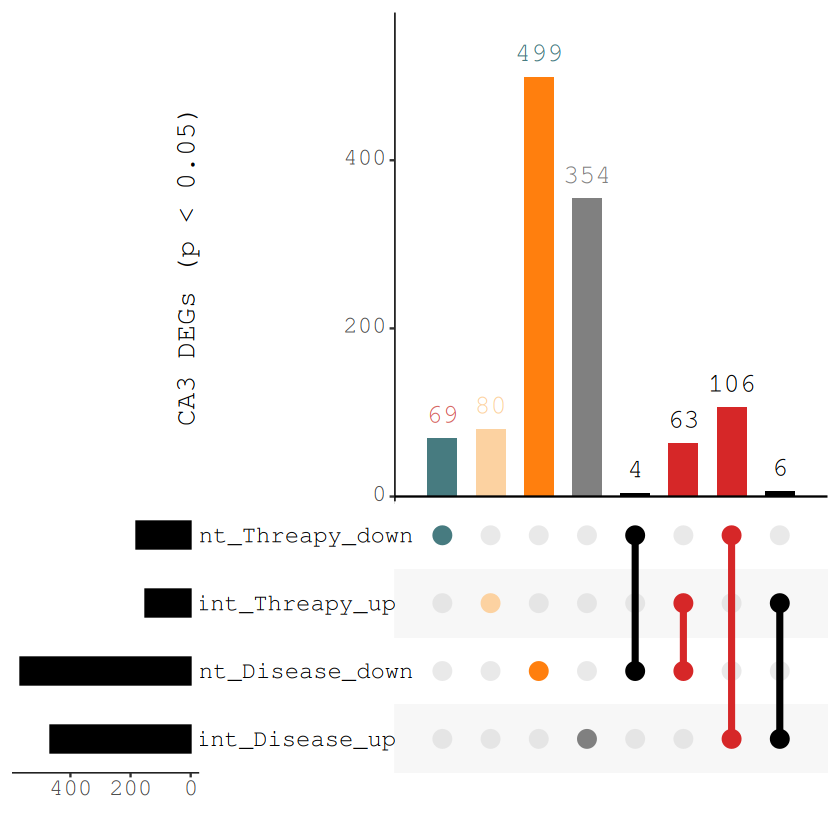

In [31]:
p

In [32]:
pdf(file = "../figure/int/2.intall.deg.pdf",width = 8,height = 6)
print(p)
dev.off()

pdf 
  2

In [ ]:
#"exc_Disease_up","exc_Disease_down","exc_Threapy_up","exc_Threapy_down"

In [33]:
down = intersect(df_list$int_Disease_up,df_list$int_Threapy_down)
up = intersect(df_list$int_Disease_down,df_list$int_Threapy_up)

In [ ]:
####---- 1. Environment Setup ----####

options(timeout = 9999999)

fig_base_dir <- "../figure/int/intall_enrich/"
out_base_dir <- "../output/int/intall_enrich/"
if(!dir.exists(fig_base_dir)) dir.create(fig_base_dir, recursive = TRUE)
if(!dir.exists(out_base_dir)) dir.create(out_base_dir, recursive = TRUE)

####---- 2. Build Data List ----####
deg_list <- list("up" = up, "down" = down ,'Totl' = c(up,down))

####---- 3. Core Loop ----####
for (direction in names(deg_list)) {
  
  message(paste0("\n>>> Processing [", direction, "] direction..."))
  current_degs <- deg_list[[direction]]
  
  # --- 1. Basic Check ---
  if (is.null(current_degs) || length(current_degs) == 0) next
  genes_to_test <- if (is.data.frame(current_degs)) as.character(current_degs[[1]]) else as.character(current_degs)
  genes_to_test <- unique(genes_to_test[!is.na(genes_to_test) & genes_to_test != ""])
  if (length(genes_to_test) < 5) { message("   Skip: too few genes"); next }
  
  # --- 2. Enrichment Analysis ---
  de_bitr <- suppressWarnings(tryCatch({
    bitr(geneID = genes_to_test, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = "org.Mm.eg.db")
  }, error = function(e) return(NULL)))
  if (is.null(de_bitr)) { message("   Skip: ID conversion failed"); next }
  
  deg_go <- suppressMessages(suppressWarnings(
    enrichGO(gene = de_bitr$ENTREZID, OrgDb = "org.Mm.eg.db", ont = "ALL", pvalueCutoff = 1, qvalueCutoff = 1)
  ))
  deg_kegg <- suppressMessages(suppressWarnings(
    enrichKEGG(gene = de_bitr$ENTREZID, organism = "mmu", pvalueCutoff = 1, qvalueCutoff = 1)
  ))
  
  # --- 3. Extract, Convert and Save Data ----
  go_df <- if(!is.null(deg_go)) as.data.frame(setReadable(deg_go, 'org.Mm.eg.db', 'ENTREZID')) else data.frame()
  kegg_df <- if(!is.null(deg_kegg)) as.data.frame(setReadable(deg_kegg, 'org.Mm.eg.db', 'ENTREZID')) else data.frame()
  
  if(nrow(go_df) > 0) {
    write.csv(go_df, paste0(out_base_dir, direction, "_GO_All_Results.csv"), row.names = FALSE)
  }
  if(nrow(kegg_df) > 0) {
    write.csv(kegg_df, paste0(out_base_dir, direction, "_KEGG_All_Results.csv"), row.names = FALSE)
  }
  
  # --- 4. Prepare Plotting Data ---
  plot_df <- bind_rows(
    if(nrow(go_df)>0) go_df %>% group_by(ONTOLOGY) %>% slice_min(order_by = pvalue, n = 10) %>% ungroup() else data.frame(),
    if(nrow(kegg_df)>0) kegg_df %>% slice_min(order_by = pvalue, n = 10) %>% mutate(ONTOLOGY = "KEGG") else data.frame()
  )
  
  if (nrow(plot_df) == 0) { message("   Skip: no items to plot"); next }
  
  plot_df <- plot_df %>%
    mutate(ONTOLOGY = factor(ONTOLOGY, levels = c("BP", "CC", "MF", "KEGG"))) %>%
    arrange(desc(ONTOLOGY), desc(pvalue)) %>%
    mutate(Description = str_trunc(Description, 60)) %>%
    mutate(Description = make.unique(Description)) %>%
    mutate(Description = factor(Description, levels = unique(Description)))

  n_terms <- nrow(plot_df)
  present_onts <- levels(droplevels(plot_df$ONTOLOGY))
  num_onts <- length(present_onts)
  
  color_map <- c("BP" = "#9e9ac8", "CC" = "#f46d43", "MF" = "#41b6c4", "KEGG" = "#74c476")
  use_colors <- unname(color_map[present_onts])

  # --- 5. Plotting ---
  p <- ggplot(plot_df, aes(x = Count, y = interaction(Description, ONTOLOGY))) + 
      geom_point(data = subset(plot_df, ONTOLOGY == "KEGG"), aes(fill = pvalue, size = Count), shape = 21) + 
      scale_fill_gradient(low = "#a1d99b", high = "#238b45", name = "KEGG p") + 
      new_scale_fill() + 
      geom_point(data = subset(plot_df, ONTOLOGY == "MF"), aes(fill = pvalue, size = Count), shape = 21) + 
      scale_fill_gradient(low = "#a6bddb", high = "#0570b0", name = "MF p") + 
      new_scale_fill() + 
      geom_point(data = subset(plot_df, ONTOLOGY == "CC"), aes(fill = pvalue, size = Count), shape = 21) + 
      scale_fill_gradient(low = "#fdd49e", high = "#d7301f", name = "CC p") + 
      new_scale_fill() +
      geom_point(data = subset(plot_df, ONTOLOGY == "BP"), aes(fill = pvalue, size = Count), shape = 21) + 
      scale_fill_gradient(low = "#8c96c6", high = "#8c6bb1", name = "BP p") + 
      
      labs(title = paste0("zhipu | ", direction, " DEGs"), x = "Gene Count", y = "") + 
      scale_size(range = c(3, 7), guide = guide_legend(override.aes = list(fill = "#000000"))) + 
      theme_bw() + 
      theme(
        ggh4x.axis.nestline.y = if(num_onts > 1) element_line(linewidth = 2, color = use_colors) else element_blank(),
        ggh4x.axis.nesttext.y = if(num_onts > 1) element_text(colour = use_colors, size = 10, face = "bold") else element_blank(),
        axis.text.y = element_text(color = "black", size = 9),
        panel.grid.major.y = element_line(linetype = "dotted", color = "grey80"),
        plot.title = element_text(hjust = 0.5, face = "bold", size = 14),
        plot.margin = margin(1, 1, 1, 1, "cm")
      )

  # --- 6. Save Plot ---
  ggsave(filename = paste0(fig_base_dir, direction, "_Pathway_Enrich.pdf"), 
         plot = p, height = 12, width = 11, device = cairo_pdf)
  
  message(paste0("    [", direction, "] Data tables and plots saved successfully"))
}

message("\nAll tasks completed successfully!")

function plot

In [2]:
exc_down = read.csv('../output/Exc/excall_enrich/down_GO_All_Results.csv')

In [3]:
library(stringr)

exc_down$Description <- str_remove(
    exc_down$Description,
    " - Mus musculus \\(house mouse\\)$"
)

In [5]:
dt = exc_down[,c('Description','pvalue','geneID')]
colnames(dt)[2] = 'Pvalue' 
dt = dt[1:10,]
dt$Cluster = 'Down'

In [ ]:
source('~/hanshu/plot_enrich_bar.R')

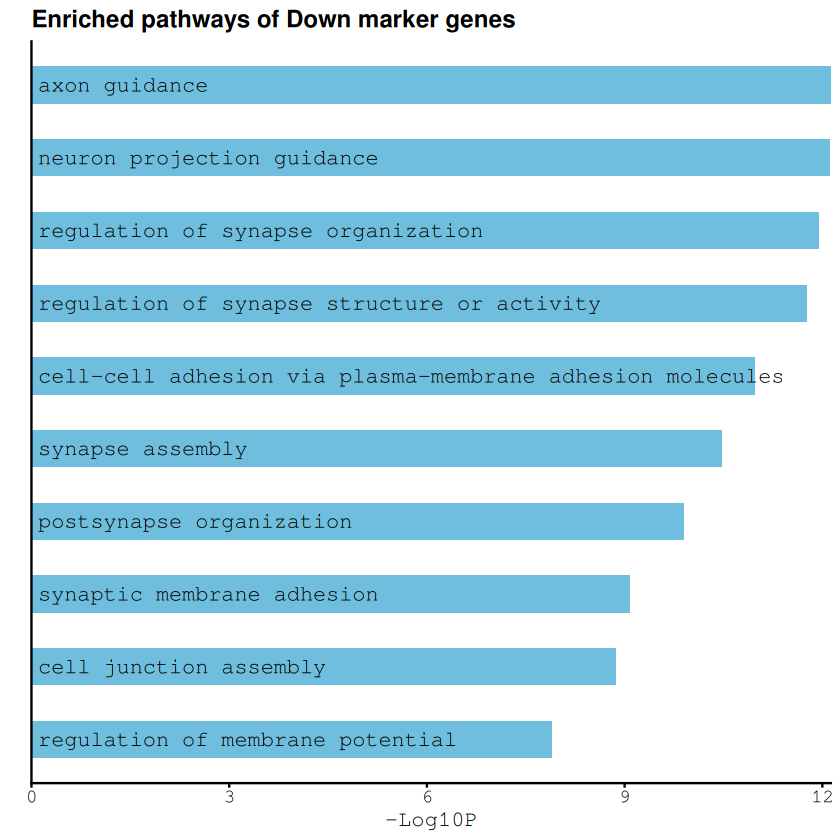

In [ ]:

p <- plot_enrich_bar(
  data = dt,
  title = "Enriched pathways of Down marker genes",
  xlab = "-Log10P",
  #ylab = "Microglia3 Microglia2",
  #gene_col = NULL, 
  show_gene = F,
  fill_colors = c( "#6fbedd")#"#6fbedd",
)

p

In [8]:
ggsave2(p,filename = '../figure/Exc/1.esc.down.kegg.top10.pdf',width = 5,height = 6)

In [9]:
exc_up = read.csv('../output/Exc/excall_enrich/up_KEGG_All_Results.csv')
library(stringr)

exc_up$Description <- str_remove(
    exc_up$Description,
    " - Mus musculus \\(house mouse\\)$"
)

In [10]:
dt = exc_up[,c('Description','pvalue','geneID')]
colnames(dt)[2] = 'Pvalue' 
dt = dt[1:10,]
dt$Cluster = 'Up'

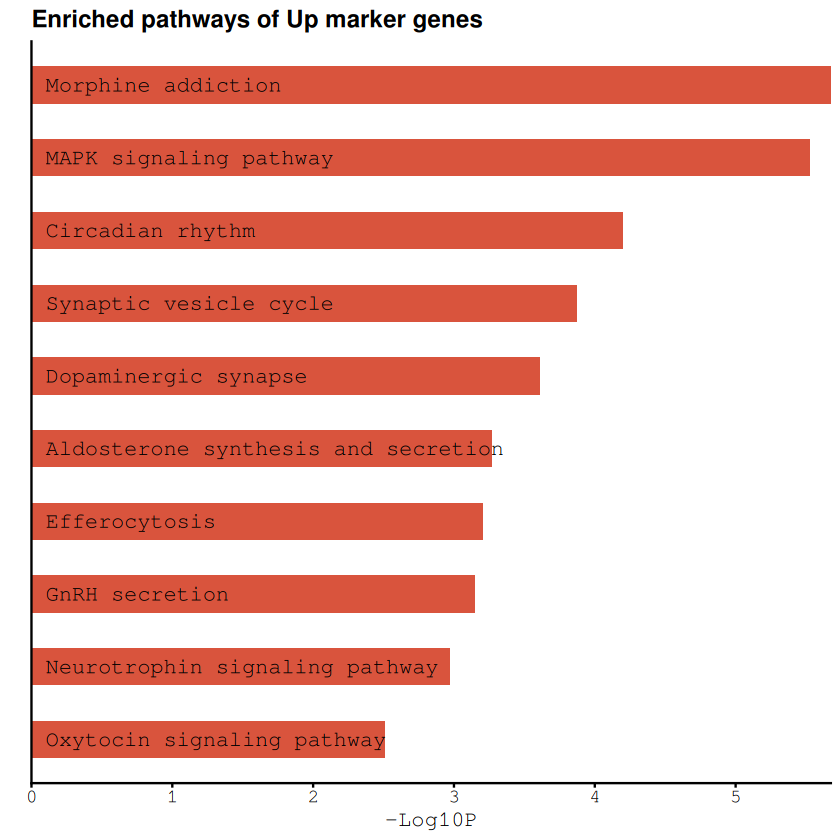

In [ ]:
p2 <- plot_enrich_bar(
  data = dt,
  title = "Enriched pathways of Up marker genes",
  xlab = "-Log10P",
  #ylab = "Microglia3 Microglia2",
  #gene_col = NULL, 
  show_gene = F,
  fill_colors = c("#d9543d")#"#6fbedd",
)

p2

In [12]:
ggsave2(p2,filename = '../figure/Exc/2.exc.up.kegg.top10.pdf',width = 5,height = 6)

Int

In [2]:
Int_up = read.csv('../output/int/intall_enrich/up_KEGG_All_Results.csv')
library(stringr)

Int_up$Description <- str_remove(
    Int_up$Description,
    " - Mus musculus \\(house mouse\\)$"
)

In [3]:
dt = Int_up[,c('Description','pvalue','geneID')]
colnames(dt)[2] = 'Pvalue' 
dt = dt[1:10,]
dt$Cluster = 'Up'

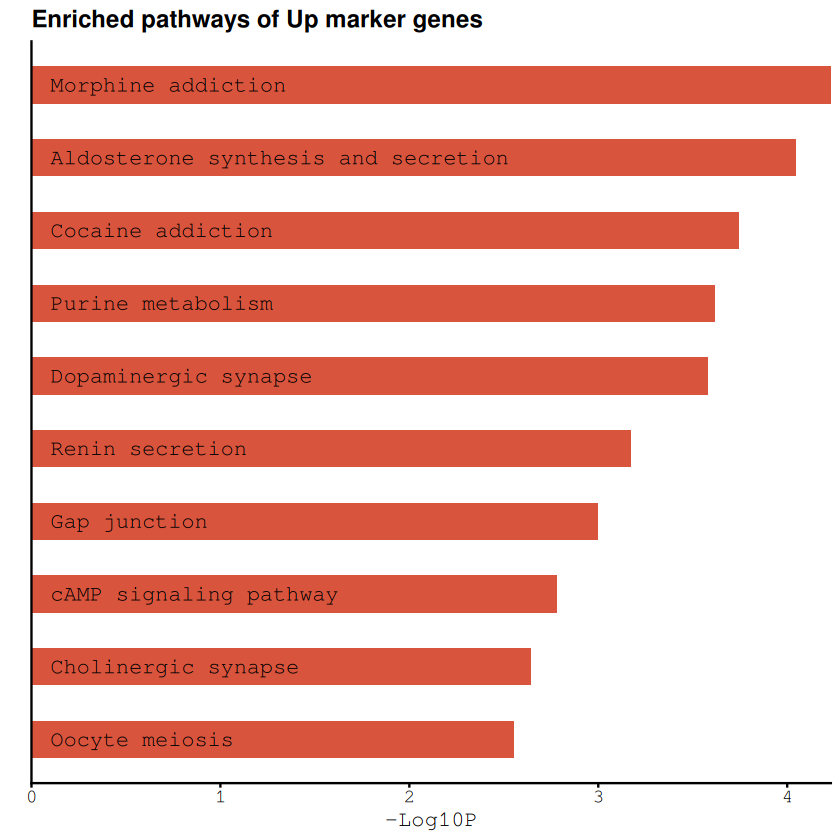

In [ ]:
p3 <- plot_enrich_bar(
  data = dt,
  title = "Enriched pathways of Up marker genes",
  xlab = "-Log10P",
  #ylab = "Microglia3 Microglia2",
  #gene_col = NULL, 
  show_gene = F,
  fill_colors = c("#d9543d")#"#6fbedd",
)

p3

In [7]:
ggsave2(p3,filename = '../figure/int/3.int.gene.up.enrich.pdf',width = 5,height = 6)

In [8]:
Int_down = read.csv('../output/int/intall_enrich/down_KEGG_All_Results.csv')
library(stringr)

Int_down$Description <- str_remove(
    Int_down$Description,
    " - Mus musculus \\(house mouse\\)$"
)

In [9]:
dt = Int_down[,c('Description','pvalue','geneID')]
colnames(dt)[2] = 'Pvalue' 
dt = dt[1:10,]
dt$Cluster = 'Down'

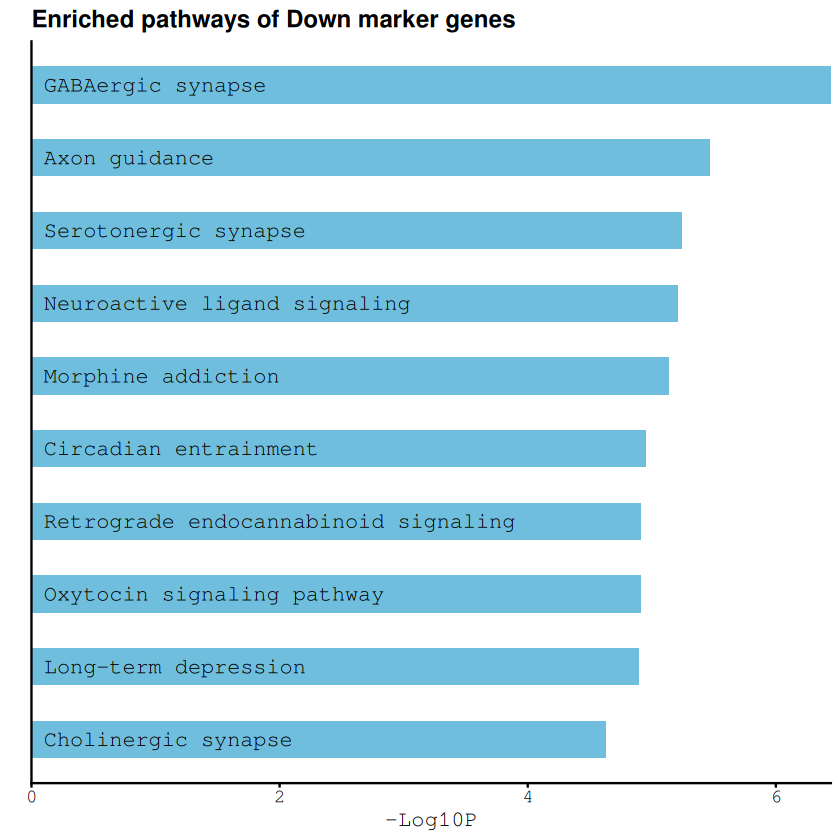

In [ ]:
p4 <- plot_enrich_bar(
  data = dt,
  title = "Enriched pathways of Down marker genes",
  xlab = "-Log10P",
  #ylab = "Microglia3 Microglia2",
  #gene_col = NULL, 
  show_gene = F,
  fill_colors = c("#6fbedd")#"#6fbedd",
)

p4

In [11]:
ggsave2(p4,filename = '../figure/int/4.int.gene.down.enrich.pdf',width = 5,height = 6)